<a href="https://colab.research.google.com/github/frevyorencia/objectdetectionbananaapple/blob/main/applebanana_data_downloader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
#
# Install Hugging Face datasets library
!pip install datasets

In [12]:
# Mount Google Drive to save files permanently (so you don't lose them)
from google.colab import drive
drive.mount('/content/drive')

# Create a folder in your Drive to save the dataset
!mkdir -p "/content/drive/MyDrive/apple_banana_dataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
from datasets import load_dataset
from PIL import Image
from pathlib import Path
import shutil
import os

# Change this to save to Drive (recommended) OR use local Colab storage
SAVE_TO_DRIVE = True  # Set to False to save locally (temporary)

if SAVE_TO_DRIVE:
    save_root = Path("/content/drive/MyDrive/apple_banana_dataset")
else:
    save_root = Path("/content/apple_banana_dataset")

# Create the folder structure
(save_root / "apple" / "images").mkdir(parents=True, exist_ok=True)
(save_root / "apple" / "labels").mkdir(parents=True, exist_ok=True)
(save_root / "banana" / "images").mkdir(parents=True, exist_ok=True)
(save_root / "banana" / "labels").mkdir(parents=True, exist_ok=True)

print("Downloading dataset from Hugging Face...")
print("(This may take a few minutes)")

# Load the dataset
dataset = load_dataset("JadeRay-42/Friut-Detection", split="train")

# Filter and save
apple_count = 0
banana_count = 0

for idx, sample in enumerate(dataset):
    categories = sample["objects"]["category"]

    if 0 in categories:  # Apple
        fruit_type = "apple"
        apple_count += 1
    elif 1 in categories:  # Banana
        fruit_type = "banana"
        banana_count += 1
    else:
        continue  # Skip images without apple or banana

    # Save image
    image = sample["image"]
    img_filename = f"{fruit_type}_{apple_count if fruit_type=='apple' else banana_count}.jpg"
    img_path = save_root / fruit_type / "images" / img_filename
    image.save(img_path)

    # Save annotations as YOLO format .txt
    img_w, img_h = image.size
    label_filename = f"{fruit_type}_{apple_count if fruit_type=='apple' else banana_count}.txt"
    label_path = save_root / fruit_type / "labels" / label_filename

    with open(label_path, "w") as f:
        for bbox, cat in zip(sample["objects"]["bbox"], categories):
            if (fruit_type == "apple" and cat == 0) or (fruit_type == "banana" and cat == 1):
                # Convert Pascal VOC bbox to YOLO format
                x_min, y_min, x_max, y_max = bbox
                x_center = (x_min + x_max) / 2 / img_w
                y_center = (y_min + y_max) / 2 / img_h
                width = (x_max - x_min) / img_w
                height = (y_max - y_min) / img_h
                class_id = 0 if fruit_type == "apple" else 1
                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

    # Show progress every 20 images
    if (idx + 1) % 20 == 0:
        print(f"Processed {idx + 1} images... (Apples: {apple_count}, Bananas: {banana_count})")

print(f"\n✅ Complete!")
print(f"   Saved {apple_count} apple images to: {save_root}/apple/")
print(f"   Saved {banana_count} banana images to: {save_root}/banana/")

(This may take a few minutes)
Processed 20 images... (Apples: 20, Bananas: 0)
Processed 40 images... (Apples: 40, Bananas: 0)
Processed 60 images... (Apples: 60, Bananas: 0)
Processed 80 images... (Apples: 75, Bananas: 5)
Processed 100 images... (Apples: 75, Bananas: 25)
Processed 120 images... (Apples: 75, Bananas: 45)
Processed 140 images... (Apples: 75, Bananas: 65)
Processed 160 images... (Apples: 84, Bananas: 76)

✅ Complete!
   Saved 90 apple images to: /content/drive/MyDrive/apple_banana_dataset/apple/
   Saved 77 banana images to: /content/drive/MyDrive/apple_banana_dataset/banana/


In [14]:
# Check what was downloaded
import os

if SAVE_TO_DRIVE:
    save_root = Path("/content/drive/MyDrive/apple_banana_dataset")
else:
    save_root = Path("/content/apple_banana_dataset")

print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

for fruit in ["apple", "banana"]:
    img_dir = save_root / fruit / "images"
    label_dir = save_root / fruit / "labels"

    num_images = len(list(img_dir.glob("*.jpg"))) if img_dir.exists() else 0
    num_labels = len(list(label_dir.glob("*.txt"))) if label_dir.exists() else 0

    print(f"\n{fruit.upper()}:")
    print(f"  - Images: {num_images}")
    print(f"  - Labels: {num_labels}")
    print(f"  - Path: {save_root}/{fruit}/")

DATASET SUMMARY

APPLE:
  - Images: 90
  - Labels: 90
  - Path: /content/drive/MyDrive/apple_banana_dataset/apple/

BANANA:
  - Images: 77
  - Labels: 77
  - Path: /content/drive/MyDrive/apple_banana_dataset/banana/


Showing random samples with bounding boxes:


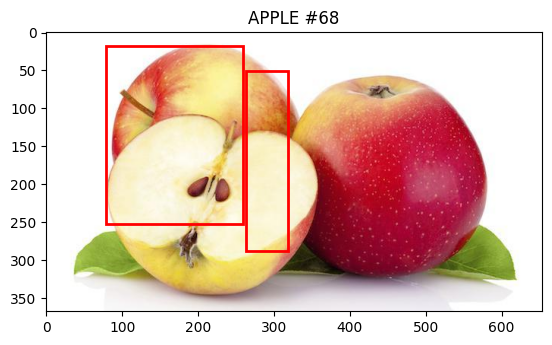

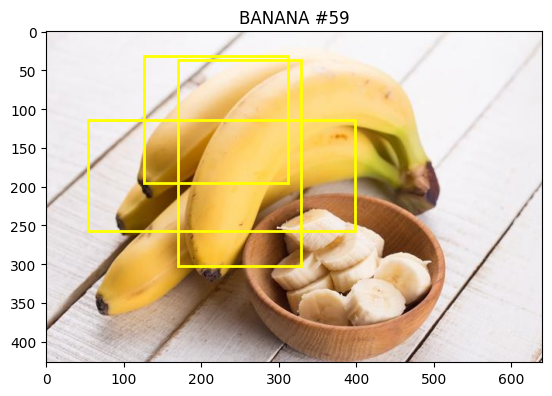

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def show_sample(fruit_type, sample_num):
    save_root = Path("/content/drive/MyDrive/apple_banana_dataset") if SAVE_TO_DRIVE else Path("/content/apple_banana_dataset")

    img_path = save_root / fruit_type / "images" / f"{fruit_type}_{sample_num}.jpg"
    label_path = save_root / fruit_type / "labels" / f"{fruit_type}_{sample_num}.txt"

    if not img_path.exists():
        print(f"Sample {sample_num} not found")
        return

    # Load image
    img = plt.imread(img_path)
    fig, ax = plt.subplots(1)
    ax.imshow(img)

    # Load and draw bounding boxes
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                class_id, x_c, y_c, w, h = map(float, line.strip().split())

                # Convert YOLO to pixel coordinates
                img_h, img_w = img.shape[:2]
                x = (x_c - w/2) * img_w
                y = (y_c - h/2) * img_h
                width = w * img_w
                height = h * img_h

                color = 'red' if class_id == 0 else 'yellow'
                rect = patches.Rectangle((x, y), width, height,
                                        linewidth=2, edgecolor=color, facecolor='none')
                ax.add_patch(rect)

    ax.set_title(f"{fruit_type.upper()} #{sample_num}")
    plt.show()

# Show random samples
print("Showing random samples with bounding boxes:")
show_sample("apple", random.randint(1, apple_count))
show_sample("banana", random.randint(1, banana_count))

In [17]:
# Zip the dataset so you can download it easily
from google.colab import files
import zipfile
import os

def zip_and_download(folder_path, zip_name):
    # Create a zip file
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, file_list in os.walk(folder_path):  # Changed 'files' to 'file_list'
            for file_name in file_list:  # Changed 'file' to 'file_name'
                file_path = os.path.join(root, file_name)
                # Preserve folder structure in the zip
                arcname = os.path.relpath(file_path, os.path.dirname(folder_path))
                zipf.write(file_path, arcname)

    # Download the zip file
    files.download(zip_name)  # Now 'files' refers to the google.colab.files module
    print(f"✅ Created and downloading: {zip_name}")

# Determine the correct path based on your save location
if SAVE_TO_DRIVE:
    zip_and_download("/content/drive/MyDrive/apple_banana_dataset", "apple_banana_dataset.zip")
else:
    zip_and_download("/content/apple_banana_dataset", "apple_banana_dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Created and downloading: apple_banana_dataset.zip


In [18]:
# Cell 7: Organize into YOLOv8 format
import shutil
from pathlib import Path
import random

# Set paths (use the same SAVE_TO_DRIVE setting from Cell 3)
SAVE_TO_DRIVE = True  # Set to False if you didn't save to Drive

if SAVE_TO_DRIVE:
    source_root = Path("/content/drive/MyDrive/apple_banana_dataset")
    yolo_root = Path("/content/drive/MyDrive/yolov8_dataset")
else:
    source_root = Path("/content/apple_banana_dataset")
    yolo_root = Path("/content/yolov8_dataset")

# Create YOLOv8 folder structure
(yolo_root / "images" / "train").mkdir(parents=True, exist_ok=True)
(yolo_root / "images" / "val").mkdir(parents=True, exist_ok=True)
(yolo_root / "labels" / "train").mkdir(parents=True, exist_ok=True)
(yolo_root / "labels" / "val").mkdir(parents=True, exist_ok=True)

# Collect all images and labels
all_files = []
for fruit in ["apple", "banana"]:
    img_dir = source_root / fruit / "images"
    label_dir = source_root / fruit / "labels"

    if img_dir.exists() and label_dir.exists():
        for img_file in img_dir.glob("*.jpg"):
            label_file = label_dir / f"{img_file.stem}.txt"
            if label_file.exists():
                all_files.append((img_file, label_file))

print(f"Found {len(all_files)} total images with labels")

# Split into train (80%) and val (20%)
random.seed(42)  # For reproducible split
random.shuffle(all_files)
split_idx = int(len(all_files) * 0.8)
train_files = all_files[:split_idx]
val_files = all_files[split_idx:]

# Copy train files
for img_file, label_file in train_files:
    shutil.copy(img_file, yolo_root / "images" / "train" / img_file.name)
    shutil.copy(label_file, yolo_root / "labels" / "train" / label_file.name)

# Copy val files
for img_file, label_file in val_files:
    shutil.copy(img_file, yolo_root / "images" / "val" / img_file.name)
    shutil.copy(label_file, yolo_root / "labels" / "val" / label_file.name)

print(f"\n✅ Organized for YOLOv8:")
print(f"   Train: {len(train_files)} images + labels")
print(f"   Val: {len(val_files)} images + labels")
print(f"   Location: {yolo_root}")

# Create data.yaml config file
data_yaml = f"""# YOLOv8 Dataset Configuration
path: {yolo_root.absolute()}
train: images/train
val: images/val

nc: 2  # number of classes (apple, banana)
names: ['apple', 'banana']
"""

with open(yolo_root / "data.yaml", "w") as f:
    f.write(data_yaml.strip())

print(f"\n✅ Created data.yaml at {yolo_root / 'data.yaml'}")
print(f"\n📊 Dataset ready for YOLOv8 training!")


Found 167 total images with labels

✅ Organized for YOLOv8:
   Train: 133 images + labels
   Val: 34 images + labels
   Location: /content/drive/MyDrive/yolov8_dataset

✅ Created data.yaml at /content/drive/MyDrive/yolov8_dataset/data.yaml

📊 Dataset ready for YOLOv8 training!
